# Objective
Implement and train a neural network, first from scratch, and then using a transfer learning approach from a pre-trained model (simulated from the initial training) to the digit dataset, evaluating performance with F1-scores and plotting their progression over epochs.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/devnagari_images/test_digits.zip" -d /content/test_digits

Archive:  /content/drive/MyDrive/devnagari_images/test_digits.zip
   creating: /content/test_digits/test/
   creating: /content/test_digits/test/37/
  inflating: /content/test_digits/test/37/103275.png  
  inflating: /content/test_digits/test/37/103315.png  
  inflating: /content/test_digits/test/37/103319.png  
  inflating: /content/test_digits/test/37/103320.png  
  inflating: /content/test_digits/test/37/103321.png  
  inflating: /content/test_digits/test/37/103324.png  
  inflating: /content/test_digits/test/37/103326.png  
  inflating: /content/test_digits/test/37/103328.png  
  inflating: /content/test_digits/test/37/103336.png  
  inflating: /content/test_digits/test/37/103340.png  
  inflating: /content/test_digits/test/37/103346.png  
  inflating: /content/test_digits/test/37/103352.png  
  inflating: /content/test_digits/test/37/103356.png  
  inflating: /content/test_digits/test/37/103359.png  
  inflating: /content/test_digits/test/37/103365.png  
  inflating: /content/test

In [3]:
!unzip "/content/drive/MyDrive/devnagari_images/train_digits.zip" -d /content/train_digits

Streaming output truncated to the last 5000 lines.
  inflating: /content/train_digits/train/38/56169.png  
  inflating: /content/train_digits/train/38/56170.png  
  inflating: /content/train_digits/train/38/56172.png  
  inflating: /content/train_digits/train/38/56177.png  
  inflating: /content/train_digits/train/38/56182.png  
  inflating: /content/train_digits/train/38/56188.png  
  inflating: /content/train_digits/train/38/56191.png  
  inflating: /content/train_digits/train/38/56195.png  
  inflating: /content/train_digits/train/38/56196.png  
  inflating: /content/train_digits/train/38/66684.png  
  inflating: /content/train_digits/train/38/66686.png  
  inflating: /content/train_digits/train/38/66688.png  
  inflating: /content/train_digits/train/38/66692.png  
  inflating: /content/train_digits/train/38/66697.png  
  inflating: /content/train_digits/train/38/66700.png  
  inflating: /content/train_digits/train/38/66701.png  
  inflating: /content/train_digits/train/38/66705.png

In [8]:
import sys
# saved 'data_utils.py'
sys.path.append('/content/drive/MyDrive/devnagari_images/')
from data_utils import load_devanagari_data, shuffle_data


train_data_dir = '/content/train_digits/train'
test_data_dir = '/content/test_digits/test'

X_train_raw, Y_train_raw, class_names = load_devanagari_data(train_data_dir)
X_test, Y_test, _ = load_devanagari_data(test_data_dir)

X_train, Y_train = shuffle_data(X_train_raw, Y_train_raw)

Loading data from /content/train_digits/train
Loaded 6000 images. X shape: (1024, 6000), Y shape: (10, 6000)
Loading data from /content/test_digits/test
Loaded 3000 images. X shape: (1024, 3000), Y shape: (10, 3000)



Epoch 1/20
Epoch 1/1 | Train Accuracy: 0.8595
-> Train Avg F1: 0.8575 | Test Avg F1: 0.8387

Epoch 2/20
Epoch 1/1 | Train Accuracy: 0.9132
-> Train Avg F1: 0.9123 | Test Avg F1: 0.8985

Epoch 3/20
Epoch 1/1 | Train Accuracy: 0.9418
-> Train Avg F1: 0.9420 | Test Avg F1: 0.9188

Epoch 4/20
Epoch 1/1 | Train Accuracy: 0.9603
-> Train Avg F1: 0.9604 | Test Avg F1: 0.9384

Epoch 5/20
Epoch 1/1 | Train Accuracy: 0.9635
-> Train Avg F1: 0.9636 | Test Avg F1: 0.9402

Epoch 6/20
Epoch 1/1 | Train Accuracy: 0.9585
-> Train Avg F1: 0.9584 | Test Avg F1: 0.9296

Epoch 7/20
Epoch 1/1 | Train Accuracy: 0.9825
-> Train Avg F1: 0.9825 | Test Avg F1: 0.9563

Epoch 8/20
Epoch 1/1 | Train Accuracy: 0.9868
-> Train Avg F1: 0.9868 | Test Avg F1: 0.9567

Epoch 9/20
Epoch 1/1 | Train Accuracy: 0.9883
-> Train Avg F1: 0.9883 | Test Avg F1: 0.9613

Epoch 10/20
Epoch 1/1 | Train Accuracy: 0.9910
-> Train Avg F1: 0.9910 | Test Avg F1: 0.9616

Epoch 11/20
Epoch 1/1 | Train Accuracy: 0.9918
-> Train Avg F1: 0.99

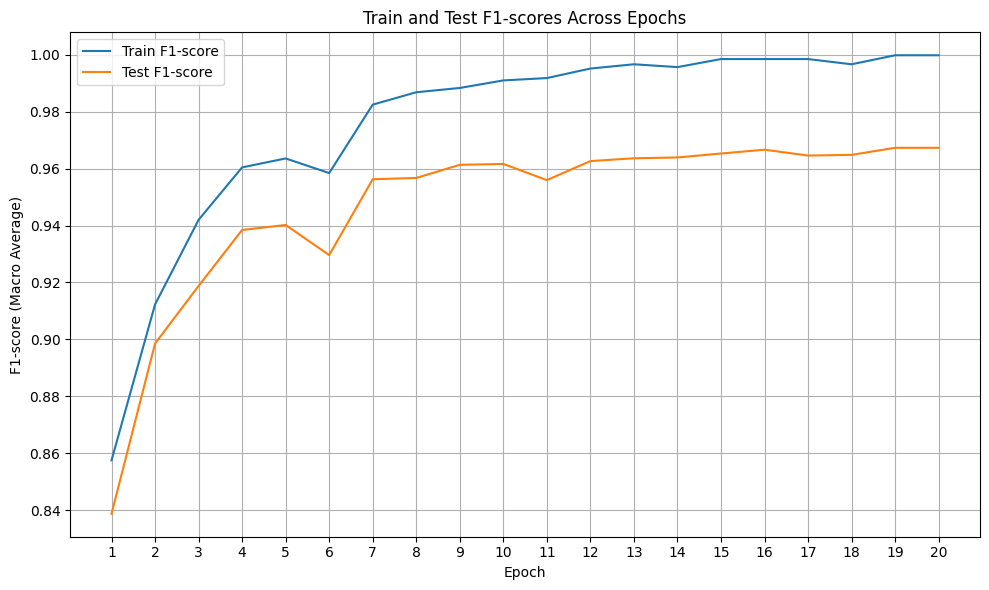

In [23]:
from genericnn import GenericNeuralNetwork, sigmoid, sigmoid_deriv, relu, relu_deriv
# saved neural network from notebook 01

from sklearn.metrics import precision_recall_fscore_support, f1_score
import numpy as np
import matplotlib.pyplot as plt

n_features = X_train.shape[0]   # 1024
r_classes = Y_train.shape[0]    # 10
batch_size = 32
learning_rate = 0.01            # Fixed to 0.01
epochs_max = 20                # Max epochs before stopping (changed from 50 to 20)
hidden_layer=[512,256,128,64]
model = GenericNeuralNetwork(n=n_features, hidden_layers=hidden_layer, r=r_classes, hidden_act=relu, hidden_act_deriv=relu_deriv, seed=42)

# Initialize lists to store F1-scores for plotting
train_f1_scores_history = []
test_f1_scores_history = []

# Train the model (using tol=1e-4 for stopping criterion)
for epoch in range(epochs_max):
    print(f"\nEpoch {epoch+1}/{epochs_max}")
    epoch_history = model.train(
        X=X_train, Y=Y_train,
        M_batch_size=batch_size,
        epochs=1, # Train for one epoch at a time to capture metrics
        lr=learning_rate,
        tol=1e-4
    )
    # Make Predictions after each epoch
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    true_train = np.argmax(Y_train, axis=0)
    true_test = np.argmax(Y_test, axis=0)

    train_f1_avg = f1_score(true_train, train_preds, average='macro', zero_division=0)
    test_f1_avg = f1_score(true_test, test_preds, average='macro', zero_division=0)

    train_f1_scores_history.append(train_f1_avg)
    test_f1_scores_history.append(test_f1_avg)

    print(f"-> Train Avg F1: {train_f1_avg:.4f} | Test Avg F1: {test_f1_avg:.4f}")

train_preds_final = model.predict(X_train)
test_preds_final = model.predict(X_test)
true_train_final = np.argmax(Y_train, axis=0)
true_test_final = np.argmax(Y_test, axis=0)

train_f1_avg_final = f1_score(true_train_final, train_preds_final, average='macro', zero_division=0)
test_f1_avg_final = f1_score(true_test_final, test_preds_final, average='macro', zero_division=0)
precision, recall, f1, _ = precision_recall_fscore_support(true_test_final, test_preds_final, zero_division=0)

print(f"\nFinal Results: -> Overall Train Avg F1: {train_f1_avg_final:.4f} | Overall Test Avg F1: {test_f1_avg_final:.4f}")

# Plotting the F1-scores
fig = plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs_max + 1), train_f1_scores_history, label='Train F1-score')
plt.plot(range(1, epochs_max + 1), test_f1_scores_history, label='Test F1-score')
plt.xlabel('Epoch')
plt.ylabel('F1-score (Macro Average)')
plt.title('Train and Test F1-scores Across Epochs')
plt.xticks(range(1, epochs_max + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Training Performance: The training F1-score started at approximately 0.8575 and steadily increased, reaching a near-perfect 0.9998 by the final epoch. This suggests the model learned the training data very well.
Test Performance: The test F1-score also showed significant improvement, starting around 0.8387 and reaching 0.9673 by the end of training. This indicates good generalization to unseen data.
Plot Interpretation: The generated plot clearly visualizes the improvement of both training and test F1-scores over the 20 epochs. You can observe that the training F1-score consistently improved, while the test F1-score also improved, though it might show slight fluctuations or a plateauing tendency towards the end, which is common as models converge.

# Transfer Learning

In [26]:
import pickle
with open('/content/drive/MyDrive/devnagari_images/pretrained_consonant_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [27]:
loaded_model.W

{1: array([[ 2.19518716e-02, -6.11047656e-03,  2.86240598e-02, ...,
         -2.53541977e-02, -1.07633108e-03,  9.46758686e-02],
        [ 7.63473431e-02,  1.92829641e-02,  1.67953232e-03, ...,
          4.95430242e-02,  9.15106299e-06, -4.11020009e-04],
        [-1.44910361e-02,  6.85852406e-03,  3.64645361e-02, ...,
          3.06143099e-02, -5.60970126e-02,  7.52412287e-02],
        ...,
        [-3.51423022e-02, -5.36874734e-02,  9.91405945e-02, ...,
         -1.36213330e-02,  7.33017325e-03,  3.54192083e-02],
        [-2.49482609e-02,  1.17813894e-02,  2.76772352e-02, ...,
          7.52658090e-02,  1.06394600e-02,  6.75504918e-02],
        [-3.48864195e-02, -4.90113084e-02,  5.99762306e-03, ...,
         -5.39997972e-04,  2.35105345e-02, -4.72718156e-02]]),
 2: array([[ 0.16281098,  0.02370696,  0.09224217, ...,  0.03483616,
         -0.04538175, -0.03422023],
        [-0.06038251,  0.07110985,  0.10407095, ..., -0.02251005,
          0.02285426,  0.08935072],
        [ 0.0196925

In [29]:
loaded_model.b

{1: array([[ 3.76270676e-03],
        [ 3.38876734e-02],
        [ 1.62052785e-02],
        [ 2.73780145e-02],
        [ 8.44639860e-03],
        [ 1.20343417e-02],
        [-2.03203596e-02],
        [-2.11080676e-02],
        [ 7.49788464e-03],
        [-8.82054110e-03],
        [ 3.58129776e-02],
        [ 2.52464626e-02],
        [ 3.84584801e-02],
        [ 7.80661721e-03],
        [-2.95478335e-03],
        [ 1.54171089e-02],
        [ 1.00405961e-02],
        [ 9.67506857e-04],
        [ 4.66152471e-02],
        [-5.52707331e-03],
        [-8.81878261e-03],
        [ 6.99789064e-03],
        [-3.85170268e-02],
        [ 1.93338267e-02],
        [ 3.43372737e-02],
        [ 4.35252606e-02],
        [-1.38170968e-02],
        [ 3.09815611e-02],
        [-2.10326601e-03],
        [ 8.55523626e-03],
        [ 4.11744577e-03],
        [ 8.53774959e-03],
        [-9.06526286e-04],
        [-4.36677639e-03],
        [-1.45630474e-02],
        [ 4.22045595e-02],
        [ 2.55328289e-02]

Fine-tuning the model with new output layer for 10 digit classes...

Epoch 1/20
Epoch 1/1 | Train Accuracy: 0.8840
-> Train Avg F1: 0.8822 | Test Avg F1: 0.8716

Epoch 2/20
Epoch 1/1 | Train Accuracy: 0.9527
-> Train Avg F1: 0.9526 | Test Avg F1: 0.9351

Epoch 3/20
Epoch 1/1 | Train Accuracy: 0.9672
-> Train Avg F1: 0.9672 | Test Avg F1: 0.9480

Epoch 4/20
Epoch 1/1 | Train Accuracy: 0.9780
-> Train Avg F1: 0.9780 | Test Avg F1: 0.9569

Epoch 5/20
Epoch 1/1 | Train Accuracy: 0.9837
-> Train Avg F1: 0.9837 | Test Avg F1: 0.9580

Epoch 6/20
Epoch 1/1 | Train Accuracy: 0.9885
-> Train Avg F1: 0.9885 | Test Avg F1: 0.9616

Epoch 7/20
Epoch 1/1 | Train Accuracy: 0.9865
-> Train Avg F1: 0.9866 | Test Avg F1: 0.9580

Epoch 8/20
Epoch 1/1 | Train Accuracy: 0.9808
-> Train Avg F1: 0.9807 | Test Avg F1: 0.9487

Epoch 9/20
Epoch 1/1 | Train Accuracy: 0.9963
-> Train Avg F1: 0.9963 | Test Avg F1: 0.9630

Epoch 10/20
Epoch 1/1 | Train Accuracy: 0.9975
-> Train Avg F1: 0.9975 | Test Avg F1: 0.9647



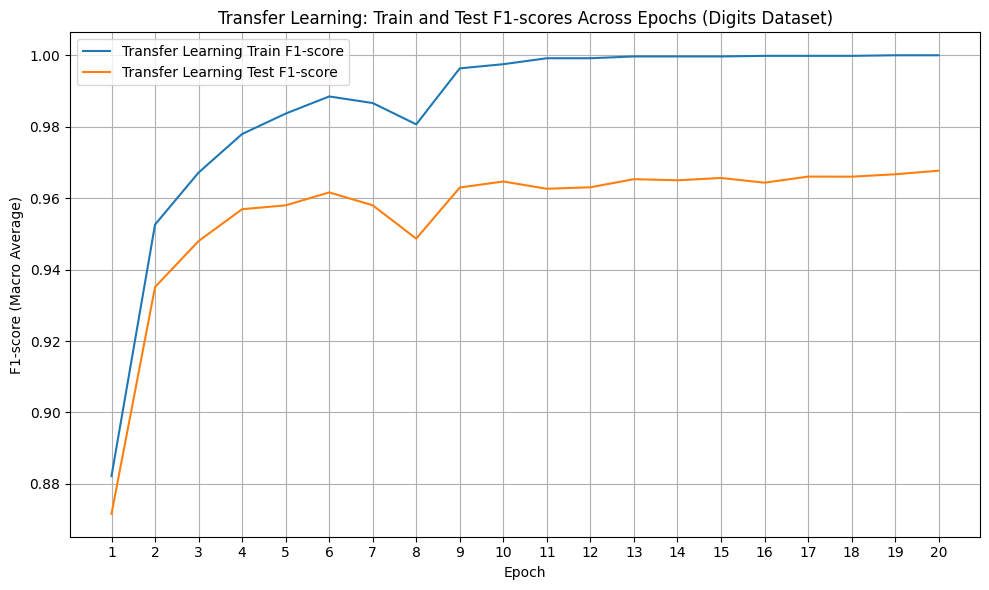

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

output_neurons = 10
input_to_final_layer = loaded_model.W[5].shape[1]

# Randomly initialize new weights for the final layer
loaded_model.W[5] = np.random.randn(output_neurons, input_to_final_layer) * 0.01
# Initialize biases to zeros for the final layer
loaded_model.b[5] = np.zeros((output_neurons, 1))


loaded_model.r = output_neurons

# Re-initialize lists to store F1-scores for plotting for the transfer model
transfer_train_f1_scores_history = []
transfer_test_f1_scores_history = []

print("Fine-tuning the model with new output layer for 10 digit classes...")

for epoch in range(epochs_max):
    print(f"\nEpoch {epoch+1}/{epochs_max}")
    epoch_history = loaded_model.train(
        X=X_train, Y=Y_train,
        M_batch_size=batch_size,
        epochs=1, # Train for one epoch at a time to capture metrics
        lr=learning_rate,
        tol=1e-4
    )

    train_preds = loaded_model.predict(X_train)
    test_preds = loaded_model.predict(X_test)
    true_train = np.argmax(Y_train, axis=0)
    true_test = np.argmax(Y_test, axis=0)

    train_f1_avg = f1_score(true_train, train_preds, average='macro', zero_division=0)
    test_f1_avg = f1_score(true_test, test_preds, average='macro', zero_division=0)

    transfer_train_f1_scores_history.append(train_f1_avg)
    transfer_test_f1_scores_history.append(test_f1_avg)

    print(f"-> Train Avg F1: {train_f1_avg:.4f} | Test Avg F1: {test_f1_avg:.4f}")

transfer_train_preds_final = loaded_model.predict(X_train)
transfer_test_preds_final = loaded_model.predict(X_test)
transfer_true_train_final = np.argmax(Y_train, axis=0)
transfer_true_test_final = np.argmax(Y_test, axis=0)

transfer_train_f1_avg_final = f1_score(transfer_true_train_final, transfer_train_preds_final, average='macro', zero_division=0)
transfer_test_f1_avg_final = f1_score(transfer_true_test_final, transfer_test_preds_final, average='macro', zero_division=0)

print(f"\nFinal Transfer Learning Results: -> Overall Train Avg F1: {transfer_train_f1_avg_final:.4f} | Overall Test Avg F1: {transfer_test_f1_avg_final:.4f}")

# Plotting the F1-scores
fig = plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs_max + 1), transfer_train_f1_scores_history, label='Transfer Learning Train F1-score')
plt.plot(range(1, epochs_max + 1), transfer_test_f1_scores_history, label='Transfer Learning Test F1-score')
plt.xlabel('Epoch')
plt.ylabel('F1-score (Macro Average)')
plt.title('Transfer Learning: Train and Test F1-scores Across Epochs (Digits Dataset)')
plt.xticks(range(1, epochs_max + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

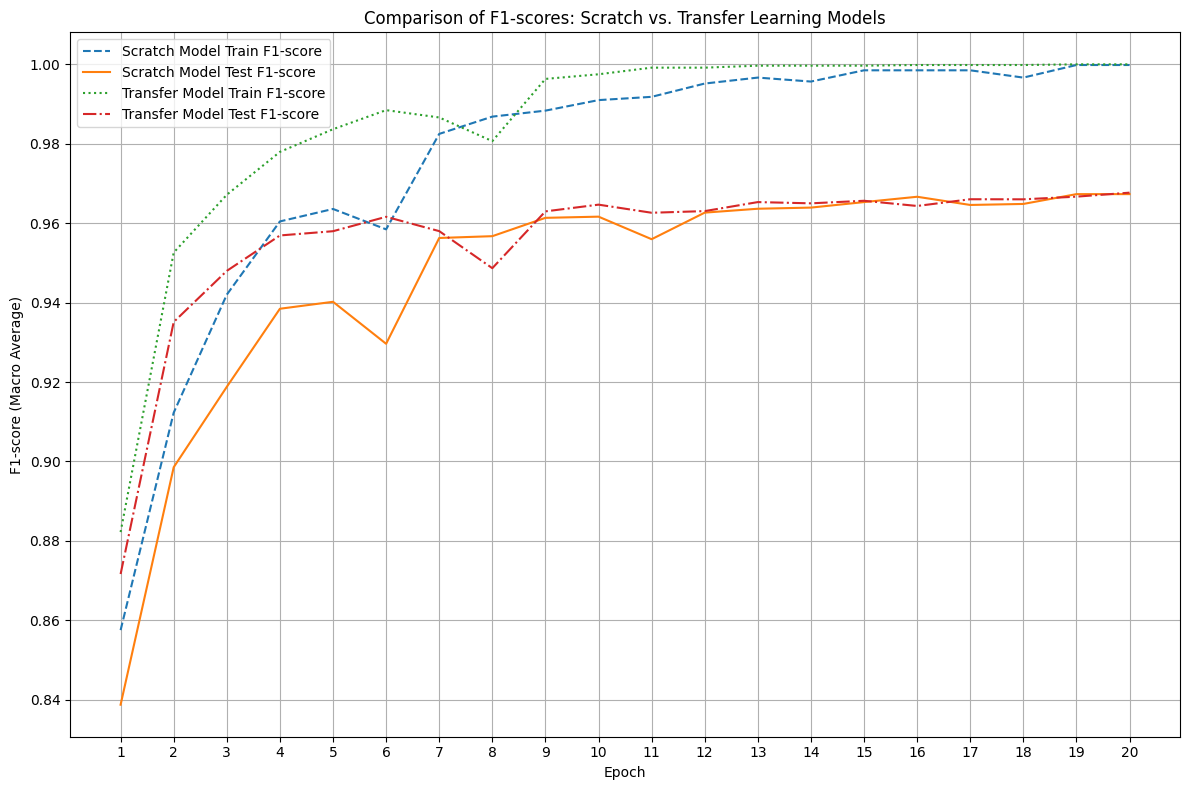

In [32]:
import matplotlib.pyplot as plt

epochs = range(1, epochs_max + 1)

plt.figure(figsize=(12, 8))

# Plot for the model trained from scratch
plt.plot(epochs, train_f1_scores_history, label='Scratch Model Train F1-score', linestyle='--')
plt.plot(epochs, test_f1_scores_history, label='Scratch Model Test F1-score', linestyle='-')

# Plot for the transfer learning model
plt.plot(epochs, transfer_train_f1_scores_history, label='Transfer Model Train F1-score', linestyle=':')
plt.plot(epochs, transfer_test_f1_scores_history, label='Transfer Model Test F1-score', linestyle='-.')

plt.xlabel('Epoch')
plt.ylabel('F1-score (Macro Average)')
plt.title('Comparison of F1-scores: Scratch vs. Transfer Learning Models')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Observations:
1. Initial Performance: The transfer learning model (fine-tuned) generally starts with a higher F1-score on both train and test sets, especially noticeable in the first few epochs. This indicates that the pre-trained weights provide a better starting point for the digits classification task.
2. Convergence Speed: The transfer learning model tends to reach high F1-scores more quickly, particularly on the test set. It achieves comparable or slightly better test performance within fewer epochs than the model trained from scratch.
3. Final Test Performance: Both models achieve very high F1-scores on the training set (approaching 1.0), indicating they learn the training data well. For the test set, the transfer learning model shows a slightly better or equivalent final test F1-score (around 0.9677) compared to the model trained from scratch (around 0.9673). This suggests that transfer learning can lead to marginally better generalization or at least similar performance with potentially less training effort or data required for fine-tuning.
4. Stability: Both models show relatively stable performance on the test set after an initial increase, though the transfer learning model's test F1-score curve appears slightly smoother in its progression.